In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


In [ ]:
from google.colab import files
import zipfile

# If your dataset is a zip, upload and unzip it
uploaded = files.upload()  # select your zip file

with zipfile.ZipFile("archive.zip", "r") as z:
    z.extractall("fer2013")

Saving archive.zip to archive.zip


In [ ]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# ── Transforms ────────────────────────────────────────────
transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

# ── Load dataset ──────────────────────────────────────────
train_dataset = datasets.ImageFolder("fer2013/train", transform=transform)
test_dataset  = datasets.ImageFolder("fer2013/test",  transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

print("Classes:", train_dataset.classes)
print("Train:", len(train_dataset), " | Test:", len(test_dataset))

# ── Check one batch ───────────────────────────────────────
imgs, labels = next(iter(train_loader))
print("Batch shape:", imgs.shape)   # should be (64, 1, 48, 48)

Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Train: 28709  | Test: 7178
Batch shape: torch.Size([64, 1, 48, 48])


In [ ]:
# ── Model ─────────────────────────────────────────────────
class EmotionCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1: (1, 48, 48) → (32, 24, 24)
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25),

            # Block 2: (32, 24, 24) → (64, 12, 12)
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25),

            # Block 3: (64, 12, 12) → (128, 6, 6)
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 6 * 6, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 7),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


# ── Sanity check ──────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = EmotionCNN().to(DEVICE)

dummy = torch.zeros(2, 1, 48, 48).to(DEVICE)
print("Output shape:", model(dummy).shape)  # should be (2, 7)

Output shape: torch.Size([2, 7])


In [ ]:
# ── Training setup ────────────────────────────────────────
lossfn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# ── Train one epoch ───────────────────────────────────────
def train_epoch(model, loader):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = lossfn(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += imgs.size(0)

    return total_loss / total, correct / total

# ── Eval one epoch ────────────────────────────────────────
def eval_epoch(model, loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs = model(imgs)
            loss = lossfn(outputs, labels)

            total_loss += loss.item() * imgs.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += imgs.size(0)

    return total_loss / total, correct / total

# ── Test: run 1 epoch ─────────────────────────────────────
train_loss, train_acc = train_epoch(model, train_loader)
print(f"train loss: {train_loss:.4f}  train acc: {train_acc:.3f}")

train loss: 1.7561  train acc: 0.292


In [ ]:
# ── Full training loop ────────────────────────────────────
EPOCHS = 150
best_val_acc = 0.0

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_epoch(model, train_loader)
    val_loss,   val_acc   = eval_epoch(model,  test_loader)

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pt")
        tag = " ← best"
    else:
        tag = ""
    if epoch % 10 == 0:
      print(f"Epoch {epoch:02d}/{EPOCHS}  "
          f"train loss: {train_loss:.4f}  acc: {train_acc:.3f}  |  "
          f"val loss: {val_loss:.4f}  acc: {val_acc:.3f}{tag}")

print(f"\nBest val accuracy: {best_val_acc:.3f}")

Epoch 10/150  train loss: 1.2960  acc: 0.502  |  val loss: 1.2031  acc: 0.540 ← best
Epoch 20/150  train loss: 1.1524  acc: 0.561  |  val loss: 1.1173  acc: 0.571 ← best
Epoch 30/150  train loss: 1.0377  acc: 0.605  |  val loss: 1.0922  acc: 0.589 ← best
Epoch 40/150  train loss: 0.9669  acc: 0.633  |  val loss: 1.1033  acc: 0.592
Epoch 50/150  train loss: 0.9074  acc: 0.655  |  val loss: 1.1019  acc: 0.598
Epoch 60/150  train loss: 0.8465  acc: 0.678  |  val loss: 1.1251  acc: 0.603
Epoch 70/150  train loss: 0.7982  acc: 0.700  |  val loss: 1.1548  acc: 0.606
Epoch 80/150  train loss: 0.7676  acc: 0.711  |  val loss: 1.1243  acc: 0.606
Epoch 90/150  train loss: 0.7275  acc: 0.726  |  val loss: 1.1775  acc: 0.609
Epoch 100/150  train loss: 0.7085  acc: 0.734  |  val loss: 1.1677  acc: 0.606
Epoch 110/150  train loss: 0.6773  acc: 0.748  |  val loss: 1.1954  acc: 0.611
Epoch 120/150  train loss: 0.6444  acc: 0.760  |  val loss: 1.2146  acc: 0.611
Epoch 130/150  train loss: 0.6291  acc: 

In [ ]:
import cv2
import torch
import numpy as np
from torchvision import transforms
from google.colab.patches import cv2_imshow
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

# ── Capture photo from webcam ─────────────────────────────
def take_photo():
    display(Javascript('''
        async function takePhoto() {
            const div = document.createElement('div');
            const capture = document.createElement('button');
            capture.textContent = 'Capture';
            div.appendChild(capture);
            const video = document.createElement('video');
            video.style.display = 'block';
            const stream = await navigator.mediaDevices.getUserMedia({video: true});
            document.body.appendChild(div);
            div.appendChild(video);
            video.srcObject = stream;
            await video.play();
            await new Promise((resolve) => capture.onclick = resolve);
            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);
            stream.getTracks().forEach(track => track.stop());
            div.remove();
            return canvas.toDataURL('image/jpeg', 0.8);
        }
        takePhoto().then(result => {
            window.lastPhoto = result;
        });
    '''))
    import time; time.sleep(5)  # wait for capture
    data = eval_js('window.lastPhoto')
    if data is None:
        print("Error: No photo data received. Make sure to allow camera access and click 'Capture' within the time limit.")
        return None
    binary = b64decode(data.split(',')[1])
    with open('photo.jpg', 'wb') as f:
        f.write(binary)
    print("Photo saved!")
    return 'photo.jpg'

photo_file = take_photo()

if photo_file:
    # ── Predict emotion ───────────────────────────────────────
    transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Grayscale(),
        transforms.Resize((48, 48)),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5])
    ])

    # Load best model
    model.load_state_dict(torch.load("best_model.pt", map_location=DEVICE))
    model.eval()

    class_names = train_dataset.classes

    img = cv2.imread(photo_file)
    if img is None:
        print("Error: Could not read the captured photo file. It might be corrupted or not exist.")
    else:
        tensor = transform(img).unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            output = model(tensor)
            probs  = torch.softmax(output, dim=1).squeeze().cpu().numpy()
            pred   = probs.argmax()

        print(f"\nEmotion: {class_names[pred].upper()}  ({probs[pred]*100:.1f}% confident)")
        for i, (name, prob) in enumerate(zip(class_names, probs)):
            bar = "█" * int(prob * 30)
            print(f"  {name:10s} {bar} {prob*100:.1f}%")


<IPython.core.display.Javascript object>

Photo saved!

Emotion: HAPPY  (43.3% confident)
  angry      █ 4.9%
  disgust     0.0%
  fear       █████ 17.1%
  happy      ████████████ 43.3%
  neutral    █████ 17.7%
  sad        ███ 11.6%
  surprise   █ 5.5%


In [ ]:
!pip install streamlit pyngrok -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 125.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 124.1 MB/s eta 0:00:00


In [ ]:
%%writefile app.py
import streamlit as st
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image
import numpy as np

# ── Model ─────────────────────────────────────────────────
class EmotionCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2), nn.Dropout2d(0.25),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2), nn.Dropout2d(0.25),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2), nn.Dropout2d(0.25),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 6 * 6, 512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, 7),
        )
    def forward(self, x):
        return self.classifier(self.features(x))

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

@st.cache_resource
def load_model():
    m = EmotionCNN().to(DEVICE)
    m.load_state_dict(torch.load("best_model.pt", map_location=DEVICE))
    m.eval()
    return m

model = load_model()
class_names = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
emojis     = ['😠',    '🤢',      '😨',   '😄',    '😐',      '😢',  '😲']

transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

# ── UI ────────────────────────────────────────────────────
st.title("😐 Facial Emotion Classifier")
st.write("Upload a face photo to detect the emotion.")

uploaded = st.file_uploader("Choose an image", type=["jpg", "jpeg", "png"])

if uploaded:
    img = Image.open(uploaded).convert("RGB")
    st.image(img, caption="Uploaded image", width=250)

    tensor = transform(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        probs = torch.softmax(model(tensor), dim=1).squeeze().cpu().numpy()

    pred = probs.argmax()
    st.markdown(f"### {emojis[pred]} Predicted: **{class_names[pred].upper()}**")
    st.markdown(f"Confidence: **{probs[pred]*100:.1f}%**")

    st.bar_chart({class_names[i]: float(probs[i]) for i in range(7)})

Writing app.py


In [ ]:
from pyngrok import ngrok
import subprocess

# IMPORTANT: Replace "YOUR_AUTHTOKEN" with your actual ngrok authtoken
# You can get one from: https://dashboard.ngrok.com/get-started/your-authtoken
ngrok.set_auth_token("3AqhTqKa4UZ20FifHdap7pjlOYS_Chw7vHAhac6roVC4fbn2")

subprocess.Popen(["streamlit", "run", "app.py", "--server.port", "8501"])
public_url = ngrok.connect(8501)
print("Open this URL:", public_url)

Open this URL: NgrokTunnel: "https://demiurgic-carlene-unwithdrawing.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
!pip install torchinfo

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

# ── Load pretrained ResNet18 ──────────────────────────────
model1 = models.resnet18(weights="IMAGENET1K_V1")

# Modify the first convolutional layer to accept 1 input channel (for grayscale images)
model1.conv1 = nn.Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)

# Modify the final classification layer to output 7 classes
num_ftrs = model1.fc.in_features
model1.fc = nn.Linear(num_ftrs, 7)

# Move the model to the appropriate device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model1 = model1.to(DEVICE)

from torchinfo import summary
summary(model1, input_size=(1, 1, 48, 48))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 7]                    --
├─Conv2d: 1-1                            [1, 64, 24, 24]           3,136
├─BatchNorm2d: 1-2                       [1, 64, 24, 24]           128
├─ReLU: 1-3                              [1, 64, 24, 24]           --
├─MaxPool2d: 1-4                         [1, 64, 12, 12]           --
├─Sequential: 1-5                        [1, 64, 12, 12]           --
│    └─BasicBlock: 2-1                   [1, 64, 12, 12]           --
│    │    └─Conv2d: 3-1                  [1, 64, 12, 12]           36,864
│    │    └─BatchNorm2d: 3-2             [1, 64, 12, 12]           128
│    │    └─ReLU: 3-3                    [1, 64, 12, 12]           --
│    │    └─Conv2d: 3-4                  [1, 64, 12, 12]           36,864
│    │    └─BatchNorm2d: 3-5             [1, 64, 12, 12]           128
│    │    └─ReLU: 3-6                    [1, 64, 12, 12]           --
│

In [ ]:
import torch
import torch.nn as nn
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# ── Transforms (224x224 for ResNet) ──────────────────────
transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

# ── Dataset ───────────────────────────────────────────────
train_dataset = datasets.ImageFolder("fer2013/train", transform=transform)
test_dataset  = datasets.ImageFolder("fer2013/test",  transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=2)

print("Classes:", train_dataset.classes)
print("Train:", len(train_dataset), "| Test:", len(test_dataset))

# ── Model ─────────────────────────────────────────────────
model = models.resnet18(weights="IMAGENET1K_V1")

# Fix input: 1 channel instead of 3
model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Unfreeze last block + classifier
for param in model.layer4.parameters():
    param.requires_grad = True
for param in model.fc.parameters():
    param.requires_grad = True

# Fix output: 7 emotions
model.fc = nn.Linear(512, 7)
model = model.to(DEVICE)

# Sanity check
dummy = torch.zeros(2, 1, 224, 224).to(DEVICE)
print("Output shape:", model(dummy).shape)  # should be (2, 7)

# ── Training setup ────────────────────────────────────────
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)

# ── Train loop ────────────────────────────────────────────
def train_epoch(model, loader):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += imgs.size(0)
    return total_loss / total, correct / total

# ── Eval loop ─────────────────────────────────────────────
def eval_epoch(model, loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * imgs.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += imgs.size(0)
    return total_loss / total, correct / total

# ── Full training loop ────────────────────────────────────
EPOCHS = 30
best_val_acc = 0.0

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_epoch(model, train_loader)
    val_loss,   val_acc   = eval_epoch(model,  test_loader)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_resnet.pt")
        tag = " ← best"
    else:
        tag = ""

    print(f"Epoch {epoch:02d}/{EPOCHS}  "
          f"train loss: {train_loss:.4f}  acc: {train_acc:.3f}  |  "
          f"val loss: {val_loss:.4f}  acc: {val_acc:.3f}{tag}")

print(f"\nBest val accuracy: {best_val_acc:.3f}")

Using device: cuda
Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Train: 28709 | Test: 7178
Output shape: torch.Size([2, 7])
Epoch 01/30  train loss: 1.3420  acc: 0.489  |  val loss: 1.1768  acc: 0.554 ← best
Epoch 02/30  train loss: 0.8599  acc: 0.691  |  val loss: 1.1407  acc: 0.588 ← best
Epoch 03/30  train loss: 0.3971  acc: 0.876  |  val loss: 1.3074  acc: 0.586
Epoch 04/30  train loss: 0.1211  acc: 0.975  |  val loss: 1.5234  acc: 0.587
Epoch 05/30  train loss: 0.0622  acc: 0.990  |  val loss: 1.6111  acc: 0.593 ← best
Epoch 06/30  train loss: 0.0457  acc: 0.992  |  val loss: 1.6797  acc: 0.592
Epoch 07/30  train loss: 0.0378  acc: 0.993  |  val loss: 1.7568  acc: 0.584
Epoch 08/30  train loss: 0.0401  acc: 0.991  |  val loss: 1.8440  acc: 0.587
Epoch 09/30  train loss: 0.0467  acc: 0.987  |  val loss: 2.0268  acc: 0.577
Epoch 10/30  train loss: 0.0491  acc: 0.986  |  val loss: 2.0032  acc: 0.585
Epoch 11/30  train loss: 0.0473  acc: 0.986  |  val lo

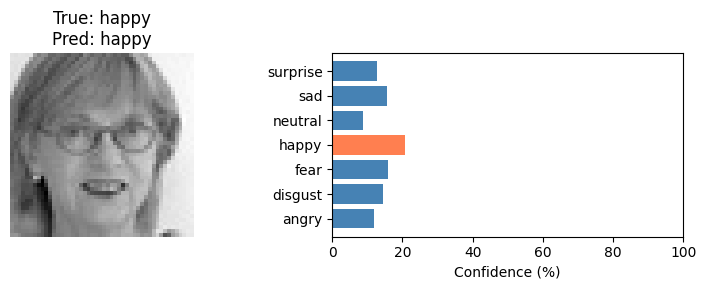

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

class_names = train_dataset.classes  # ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

def predict_one(model, dataset, idx):
    model.eval()
    img, true_label = dataset[idx]

    with torch.no_grad():
        output = model(img.unsqueeze(0).to(DEVICE))  # add batch dim
        probs  = torch.softmax(output, dim=1).squeeze().cpu().numpy()
        pred   = probs.argmax()

    # Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))

    ax1.imshow(img.squeeze().numpy() * 0.5 + 0.5, cmap="gray")
    ax1.set_title(f"True: {class_names[true_label]}\nPred: {class_names[pred]}")
    ax1.axis("off")

    colors = ["steelblue"] * 7
    colors[pred] = "coral"
    ax2.barh(class_names, probs * 100, color=colors)
    ax2.set_xlabel("Confidence (%)")
    ax2.set_xlim(0, 100)

    plt.tight_layout()
    plt.show()

# Test on a random image
idx = np.random.randint(len(test_dataset))
predict_one(model, test_dataset, idx)